In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

In [2]:

# warnings.simplefilter('ignore', np.RankWarning)
try:
    from numpy import RankWarning
    warnings.simplefilter("ignore", RankWarning)
except Exception:
    warnings.filterwarnings("ignore")

# sns.set(style="whitegrid")

buildings = ["A", "B", "C"]
building = buildings[0]


weather_observed = pd.read_parquet(f'../data/raw/{building}/X_train_observed.parquet')
weather_predicted = pd.read_parquet(f'../data/raw/{building}/X_train_estimated.parquet')
weather = pd.concat((weather_observed, weather_predicted), axis = 0)
weather = weather.set_index("date_forecast")
weather = weather.drop(columns = "date_calc")

target = pd.read_parquet(f'../data/raw/{building}/train_targets.parquet').set_index("time")
# target = target.set_index("time")

data = pd.concat((weather, target), axis=1)
data.dropna().head()
# data[data.duplicated()]
# data.dtypes

,absolute_humidity_2m:gm3,air_density_2m:kgm3,ceiling_height_agl:m,clear_sky_energy_1h:J,clear_sky_rad:W,cloud_base_agl:m,dew_or_rime:idx,dew_point_2m:K,diffuse_rad:W,diffuse_rad_1h:J,...,sun_elevation:d,super_cooled_liquid_water:kgm2,t_1000hPa:K,total_cloud_cover:p,visibility:m,wind_speed_10m:ms,wind_speed_u_10m:ms,wind_speed_v_10m:ms,wind_speed_w_1000hPa:ms,pv_measurement
2019-12-01 10:00:00,4.9,1.273,534.700012,72845.296875,30.400000,534.700012,0.0,273.299988,8.2,20024.699219,...,3.816,0.3,274.100006,100.000000,6237.500000,4.6,4.2,-1.9,0.0,66.00
2019-12-01 11:00:00,4.8,1.273,658.599976,134174.593750,41.400002,658.599976,0.0,273.000000,11.5,35375.398438,...,4.823,0.3,274.200012,99.699997,14842.500000,4.5,3.8,-2.3,0.0,41.80
2019-12-01 12:00:00,4.8,1.274,780.599976,141799.703125,34.400002,780.599976,0.0,273.100006,10.2,38937.601562,...,4.195,0.2,274.100006,99.599998,19017.500000,4.4,4.0,-1.8,0.0,4.62
2019-12-01 13:00:00,4.7,1.277,1159.199951,90073.398438,14.600000,1159.199951,0.0,272.700012,3.7,24957.900391,...,1.978,0.2,273.600006,100.000000,12991.500000,4.3,4.3,-0.8,-0.0,0.00
2019-12-01 14:00:00,4.6,1.277,1539.500000,16435.000000,0.000000,1539.500000,0.0,272.399994,0.0,6633.000000,...,-1.671,0.3,273.600006,100.000000,16517.599609,4.7,4.7,-0.5,-0.0,0.00


correlated features:
clear_sky_energy_1h:J    0.781216
clear_sky_rad:W          0.803538
diffuse_rad:W            0.702831
diffuse_rad_1h:J         0.687206
direct_rad:W             0.856095
direct_rad_1h:J          0.830861
is_day:idx               0.539552
is_in_shadow:idx        -0.576389
sun_elevation:d          0.683479
pv_measurement           1.000000
Name: pv_measurement, dtype: float64
uncorrelated features:
absolute_humidity_2m:gm3          0.236673
air_density_2m:kgm3              -0.356402
ceiling_height_agl:m              0.162789
cloud_base_agl:m                  0.157650
dew_or_rime:idx                  -0.057400
dew_point_2m:K                    0.245950
effective_cloud_cover:p          -0.216672
fresh_snow_12h:cm                -0.064208
fresh_snow_1h:cm                 -0.042882
fresh_snow_24h:cm                -0.080449
fresh_snow_3h:cm                 -0.051812
fresh_snow_6h:cm                 -0.058336
msl_pressure:hPa                  0.183326
precip_5min:mm      

(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0.5, 0, 'diffuse_rad:W'),
  Text(1.5, 0, 'diffuse_rad_1h:J'),
  Text(2.5, 0, 'direct_rad:W'),
  Text(3.5, 0, 'direct_rad_1h:J'),
  Text(4.5, 0, 'pv_measurement')])

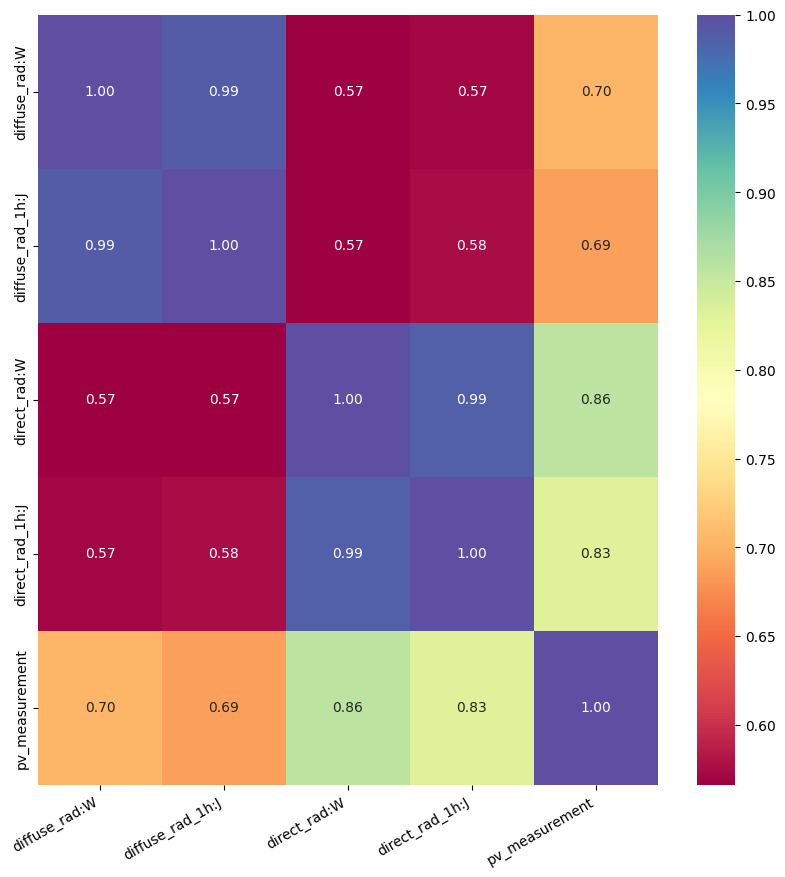

In [3]:
correlation = data.corr()["pv_measurement"]

corr_treshold = 0.5
correlated_features = correlation[correlation.abs() >= corr_treshold].index.tolist()
uncorrelated_featr = correlation[correlation.abs() < corr_treshold].index.tolist()
uncorrelated_featr.extend(['is_day:idx', 'is_in_shadow:idx', 'sun_elevation:d', 'snow_drift:idx', 'snow_density:kgm3', 'elevation:m', 'clear_sky_rad:W', 'clear_sky_energy_1h:J'])
print("correlated features:")
print(correlation[correlated_features])
print("uncorrelated features:")
print(correlation[uncorrelated_featr])
print("all features:")
print(correlation)

corrdataDF = data.drop(columns=uncorrelated_featr).dropna()
corrdataDF 

plt.figure(figsize=(10, 10))
sns.heatmap(corrdataDF.corr(), annot=True, fmt=".2f", cmap="Spectral")
plt.xticks(rotation=30, ha='right')



['absolute_humidity_2m:gm3', 'air_density_2m:kgm3', 'ceiling_height_agl:m', 'cloud_base_agl:m', 'dew_or_rime:idx', 'dew_point_2m:K', 'effective_cloud_cover:p', 'fresh_snow_12h:cm', 'fresh_snow_1h:cm', 'fresh_snow_24h:cm', 'fresh_snow_3h:cm', 'fresh_snow_6h:cm', 'msl_pressure:hPa', 'precip_5min:mm', 'precip_type_5min:idx', 'pressure_100m:hPa', 'pressure_50m:hPa', 'prob_rime:p', 'rain_water:kgm2', 'relative_humidity_1000hPa:p', 'sfc_pressure:hPa', 'snow_depth:cm', 'snow_melt_10min:mm', 'snow_water:kgm2', 'sun_azimuth:d', 'super_cooled_liquid_water:kgm2', 't_1000hPa:K', 'total_cloud_cover:p', 'visibility:m', 'wind_speed_10m:ms', 'wind_speed_u_10m:ms', 'wind_speed_v_10m:ms', 'wind_speed_w_1000hPa:ms', 'is_day:idx', 'is_in_shadow:idx', 'sun_elevation:d', 'snow_drift:idx', 'snow_density:kgm3', 'elevation:m', 'clear_sky_rad:W', 'clear_sky_energy_1h:J', 'diffuse_rad:W', 'direct_rad:W', 'diffuse_rad:W', 'direct_rad:W', 'diffuse_rad:W', 'direct_rad:W', 'diffuse_rad:W', 'direct_rad:W', 'diffuse_r

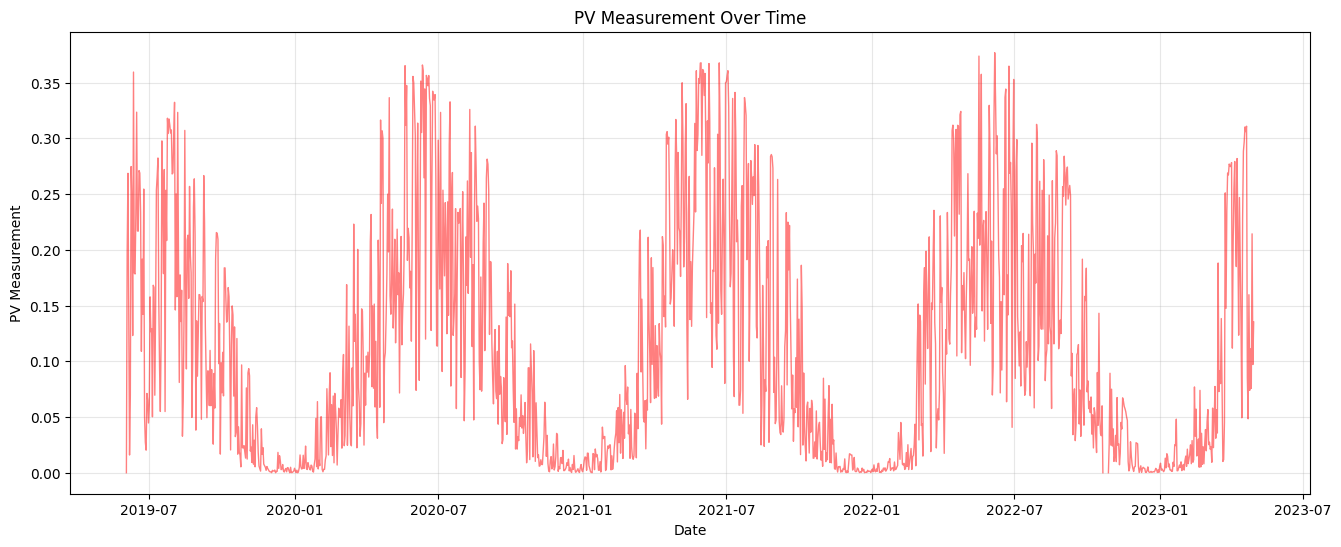

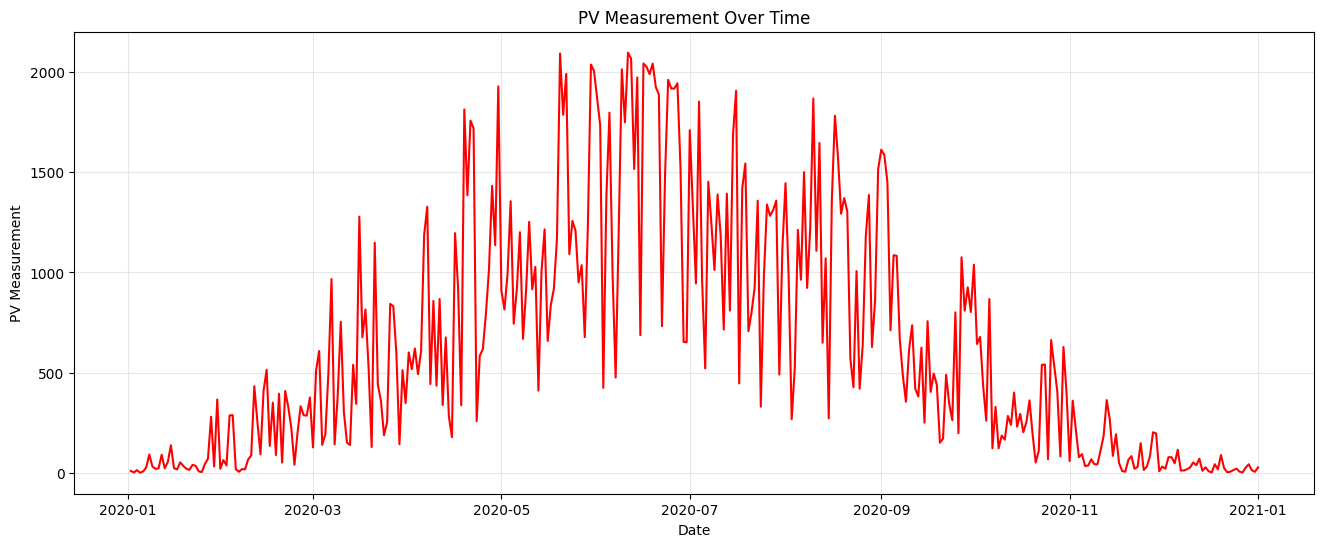

                     absolute_humidity_2m:gm3  air_density_2m:kgm3  \
2019-06-02 22:00:00                       7.7                1.230   
2019-06-02 22:15:00                       7.7                1.229   
2019-06-02 22:30:00                       7.7                1.228   
2019-06-02 22:45:00                       7.7                1.226   
2019-06-02 23:00:00                       7.7                1.225   

                     ceiling_height_agl:m  clear_sky_energy_1h:J  \
2019-06-02 22:00:00           1744.900024                    0.0   
2019-06-02 22:15:00           1734.000000                    0.0   
2019-06-02 22:30:00           1723.500000                    0.0   
2019-06-02 22:45:00           1713.400024                    0.0   
2019-06-02 23:00:00           1703.599976                    0.0   

                     clear_sky_rad:W  cloud_base_agl:m  dew_or_rime:idx  \
2019-06-02 22:00:00              0.0       1744.900024              0.0   
2019-06-02 22:15:00 

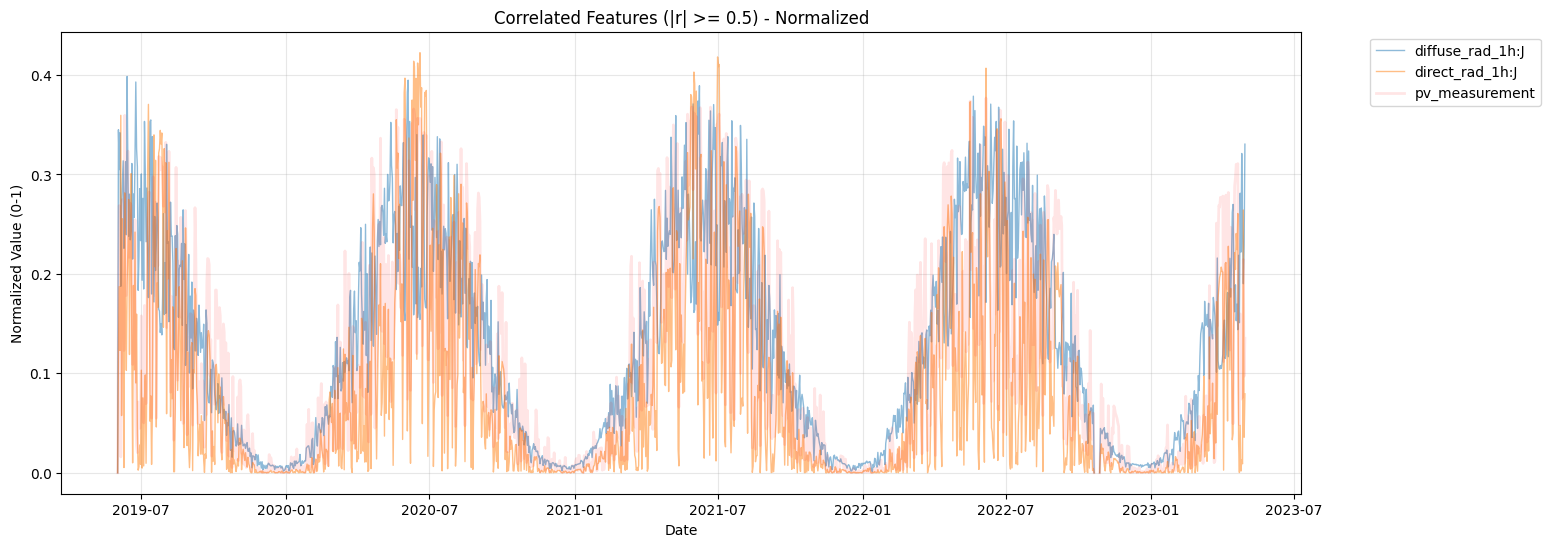

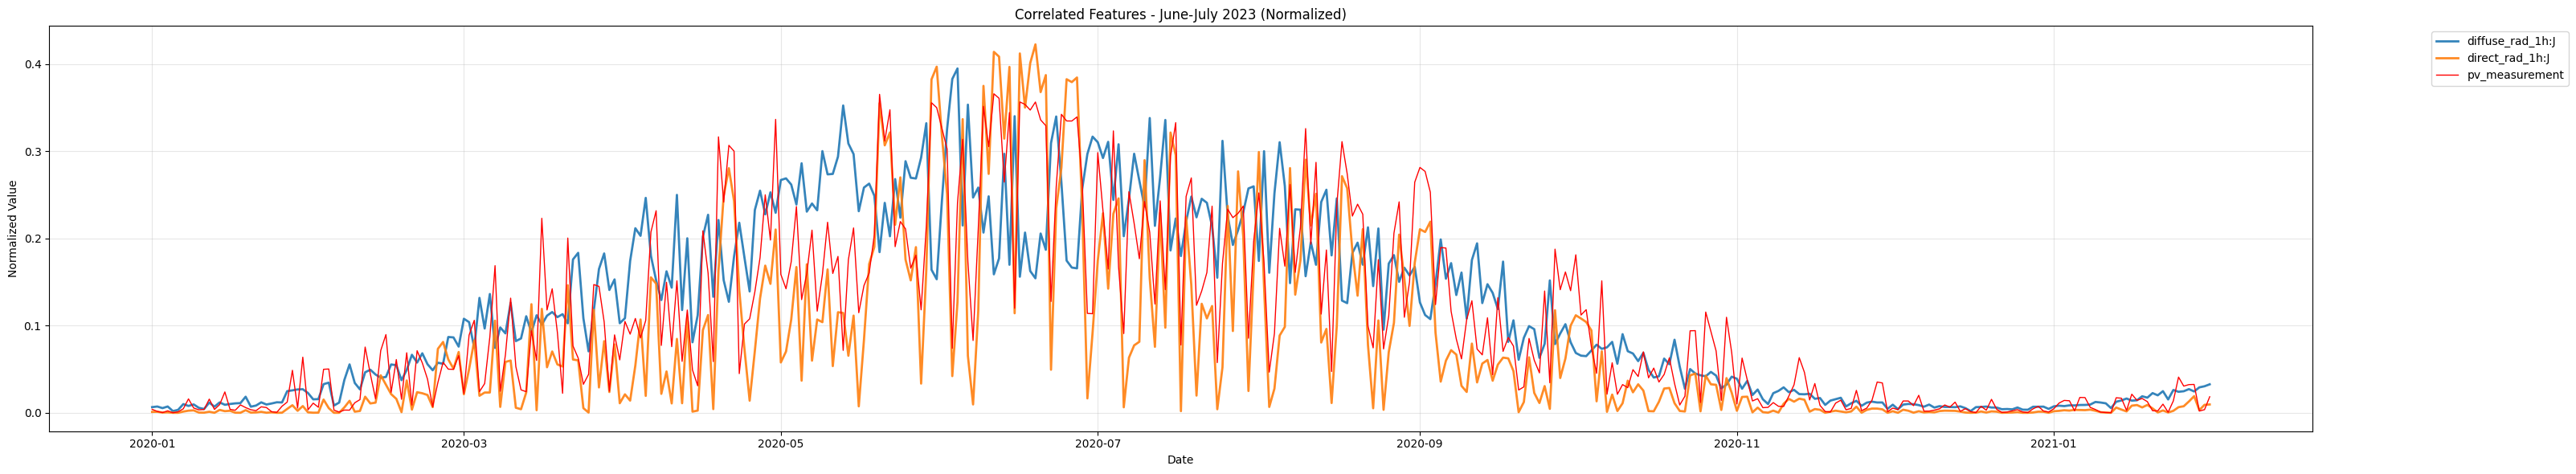

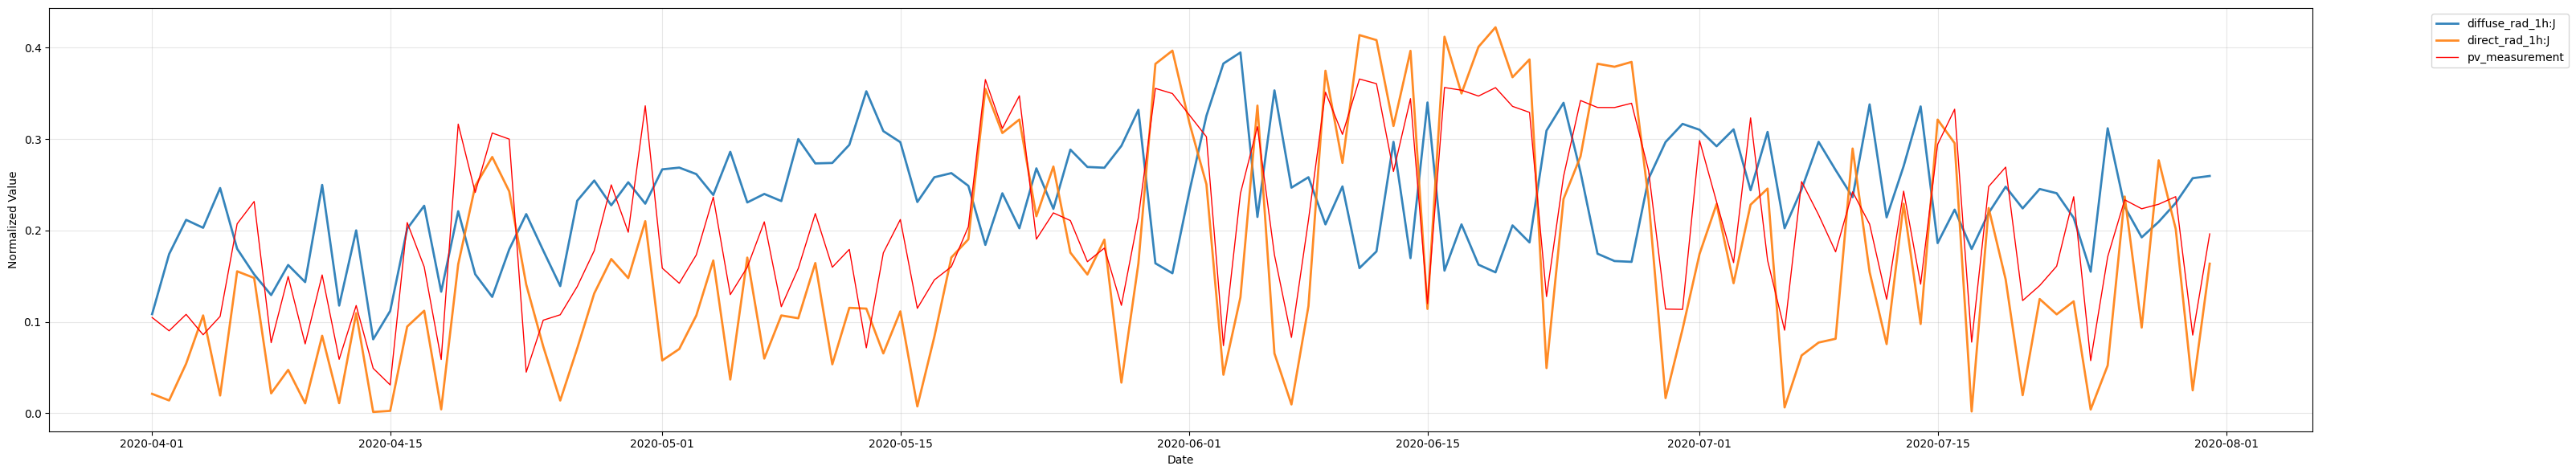

In [9]:
# ...existing code...
# Normalize features to same scale for comparison
from sklearn.preprocessing import MinMaxScaler

# Normalize correlated features to 0-1 scale
scaler = MinMaxScaler()

# corr_normalized = corrdataDF.copy()
similar_features = ["diffuse_rad:W", "direct_rad:W"]
uncorrelated_featr.extend(similar_features)
print(uncorrelated_featr)
resampledDf = data.dropna(subset=['pv_measurement']).drop(columns=uncorrelated_featr).resample('H').mean()

corr_normalized = pd.DataFrame(
    scaler.fit_transform(resampledDf),
    columns=resampledDf.columns,
    index=resampledDf.index
)
corr_normalized = corr_normalized.resample('D').mean()
resampledDf = data.dropna(subset=['pv_measurement']).drop(columns=uncorrelated_featr).resample('D').mean()

#plot pv_measurement over all years
plt.figure(figsize=(16, 6))
plt.plot(resampledDf.index, corr_normalized['pv_measurement'], color='red', alpha=0.5, linewidth=1)
# plt.plot(resampledDf.index, corr_normalized['clear_sky_rad:W'], color='blue', alpha=0.5, linewidth=1)
# plt.plot(resampledDf.index, corr_normalized['clear_sky_energy_1h:J'], color='orange', alpha=0.5, linewidth=1)
plt.title('PV Measurement Over Time')
plt.ylabel('PV Measurement')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.show()

#plot over 2020 year
start = pd.to_datetime('2020-01-01 07:00:00')
stop = pd.to_datetime('2021-01-01 07:00:00')
zoomed_data = resampledDf.loc[start:stop]
plt.figure(figsize=(16, 6))
plt.plot(zoomed_data.index, zoomed_data['pv_measurement'], color='red')
plt.title('PV Measurement Over Time')
plt.ylabel('PV Measurement')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.show()


print(data.head())
print(zoomed_data.shape)
# Plot all correlated features overlaid
plt.figure(figsize=(16, 6))
for col in corr_normalized.columns:
    if col != 'pv_measurement':
        plt.plot(corr_normalized.index, corr_normalized[col], alpha=0.5, linewidth=1, label=col)

print(corr_normalized.head())
# Highlight target in bold
plt.plot(corr_normalized.index, corr_normalized['pv_measurement'], 
         color='red', linewidth=2, label='pv_measurement', alpha=0.1)

plt.title(f'Correlated Features (|r| >= {corr_treshold}) - Normalized')
plt.ylabel('Normalized Value (0-1)')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
# plt.tight_layout()
plt.show()

# Zoomed version for better visibility
plt.figure(figsize=(32, 6))
zoom_data = corr_normalized.loc['2020-01':'2021-01']
for col in zoom_data.columns:
    if col != 'pv_measurement':
        plt.plot(zoom_data.index, zoom_data[col], alpha=0.9, linewidth=2, label=col)

plt.plot(zoom_data.index, zoom_data['pv_measurement'], 
         color='red', linewidth=1, label='pv_measurement', alpha=1)
plt.title('Correlated Features - June-July 2023 (Normalized)')
plt.ylabel('Normalized Value')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(32, 6))
zoom_data = corr_normalized.loc['2020-04':'2020-07']
for col in zoom_data.columns:
    if col != 'pv_measurement':
        plt.plot(zoom_data.index, zoom_data[col], alpha=0.9, linewidth=2, label=col)

plt.plot(zoom_data.index, zoom_data['pv_measurement'], 
         color='red', linewidth=1, label='pv_measurement', alpha=1)
plt.ylabel('Normalized Value')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# ...existing code...

# corr_normalized.dropna().sample(10)

In [ ]:
number_of_features = weather.shape[1]
fig, axes = plt.subplots(number_of_features, 1, figsize=(5, 5*number_of_features))

# weather_paramaters = pd.read_csv("weather_paramaters.csv")
# print(weather_paramaters)
plt.figure(figsize=(30, 30))
sns.heatmap(data.corr(), annot=True, fmt=".2f")

keys = corrdataDF.drop(columns=["pv_measurement"]).keys()
# print(c)

for i, feature in enumerate(keys):
    current_data = corrdataDF[[feature, "pv_measurement"]].dropna()
    axes[i].scatter(current_data[feature], current_data["pv_measurement"], alpha=0.1)
    axes[i].set(title=feature)

    print(i, feature)
    
    try:
        deg_best_fit = 2
        best_fit_polynomial = np.poly1d(np.polyfit(current_data[feature], current_data["pv_measurement"], deg_best_fit))
        unique_inputs = np.unique(current_data[feature])
        axes[i].plot(unique_inputs, best_fit_polynomial(unique_inputs), "red")
    except np.linalg.LinAlgError:
        print(f"Did not converge for {feature}")
        continue

plt.show()